# Option Pricing

In [1]:
import csv
from io import StringIO
import requests
import yfinance as yf
import math

## Fetch Real Data

In [2]:
# 1) Fetch 1 year of AAPL daily data from yfinance
aapl = yf.Ticker("AAPL")
aapl_hist = aapl.history(period="1y", interval="1d")

# Spot price
S0 = float(aapl_hist["Close"].dropna().iloc[-1])

# Annualized volatility
log_returns = (aapl_hist["Close"] / aapl_hist["Close"].shift(1)).apply(math.log).dropna()
annualized_volatility = float(log_returns.std() * math.sqrt(252))

# 2) Fetch 3-month T-bill rate (TB3MS) from FRED
# No API key needed: use FRED public CSV endpoint

csv_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=TB3MS"
resp = requests.get(csv_url, timeout=20)
resp.raise_for_status()
rows = list(csv.DictReader(StringIO(resp.text)))

tb3ms_value = None
for row in reversed(rows):
    value = row.get("TB3MS")
    if value not in (None, "", "."):
        tb3ms_value = float(value)
        break
if tb3ms_value is None:
    raise ValueError("No valid TB3MS value found in FRED CSV response.")
rf = tb3ms_value / 100.0

# 3) Dividend yield from yfinance info (returned as percent, e.g. 0.38 means 0.38%)
q = float(aapl.info.get("dividendYield") or 0.0) / 100.0

# 4) Fetch AAPL option chain from yfinance
# This creates a dictionary keyed by expiration date
option_chain = {}
for exp in aapl.options:
    chain = aapl.option_chain(exp)
    option_chain[exp] = {
        "calls": chain.calls.copy(),
        "puts": chain.puts.copy()
    }

print(f"AAPL history rows: {len(aapl_hist)}")
print(f"AAPL option expiries: {len(option_chain)}")
print(f"S0 (last AAPL close): {S0:.4f}")
print(f"rf (TB3MS as decimal): {rf:.6f}")
print(f"q  (dividend yield):   {q:.6f}")

AAPL history rows: 251
AAPL option expiries: 25
S0 (last AAPL close): 291.7150
rf (TB3MS as decimal): 0.036100
q  (dividend yield):   0.003700


## Set Parameters

In [3]:
# Parameters
T = 0.5  # 6 months in years
K = float(round(S0 * 1.02, 2))  # strike set 2% above spot
sigma = annualized_volatility

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from src.pricing import BlackScholes, MonteCarlo, BinomialTree, OptionParams

call_params = OptionParams(S=S0, K=K, T=T, r=rf, sigma=sigma, option_type="call", q=q)
put_params  = OptionParams(S=S0, K=K, T=T, r=rf, sigma=sigma, option_type="put",  q=q)

print(f"S₀={S0:.2f}  K={K:.2f}  T={T}y  r={rf:.4f}  σ={sigma:.4f}  q={q:.4f}")

S₀=291.71  K=297.55  T=0.5y  r=0.0361  σ=0.2247  q=0.0037


## Black-Scholes — Closed-Form Analytical Pricing

Computes the exact price of European call and put options under the Black-Scholes–Merton assumptions (log-normal price process, constant volatility, continuous dividend yield). This is the reference benchmark: all numerical methods are validated against it.

In [5]:
bs = BlackScholes()
bs_call = bs.price(call_params)
bs_put  = bs.price(put_params)

print(f"Black-Scholes Call: {bs_call.price:.4f}")
print(f"Black-Scholes Put:  {bs_put.price:.4f}")

Black-Scholes Call: 17.9489
Black-Scholes Put:  19.0005


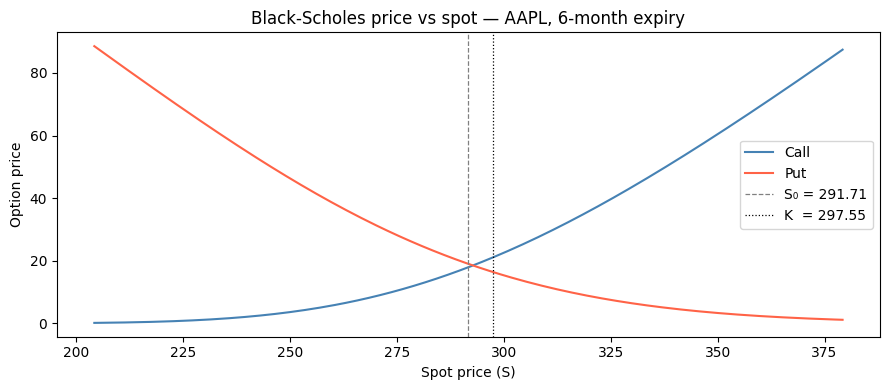

In [6]:
spot_range = np.linspace(S0 * 0.7, S0 * 1.3, 200)
bs_calls = [BlackScholes().price(OptionParams(S=s, K=K, T=T, r=rf, sigma=sigma, option_type="call", q=q)).price for s in spot_range]
bs_puts  = [BlackScholes().price(OptionParams(S=s, K=K, T=T, r=rf, sigma=sigma, option_type="put",  q=q)).price for s in spot_range]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(spot_range, bs_calls, label="Call", color="steelblue")
ax.plot(spot_range, bs_puts,  label="Put",  color="tomato")
ax.axvline(S0, linestyle="--", color="gray",  linewidth=0.9, label=f"S₀ = {S0:.2f}")
ax.axvline(K,  linestyle=":",  color="black", linewidth=0.9, label=f"K  = {K:.2f}")
ax.set_xlabel("Spot price (S)")
ax.set_ylabel("Option price")
ax.set_title("Black-Scholes price vs spot — AAPL, 6-month expiry")
ax.legend()
plt.tight_layout()
plt.show()

## Monte Carlo — Stochastic Simulation

Simulates thousands of possible price paths for AAPL under the risk-neutral GBM measure and averages the discounted payoffs. Uses antithetic variates (each random draw is paired with its mirror) to reduce variance without increasing the number of paths.

In [7]:
mc = MonteCarlo(n_paths=50_000)
mc_call = mc.price(call_params)
mc_put  = mc.price(put_params)

print(f"Monte Carlo Call (50k paths): {mc_call.price:.4f}  |  vs BS: {mc_call.price - bs_call.price:+.4f}")
print(f"Monte Carlo Put  (50k paths): {mc_put.price:.4f}  |  vs BS: {mc_put.price - bs_put.price:+.4f}")

Monte Carlo Call (50k paths): 17.9544  |  vs BS: +0.0055
Monte Carlo Put  (50k paths): 18.9908  |  vs BS: -0.0097


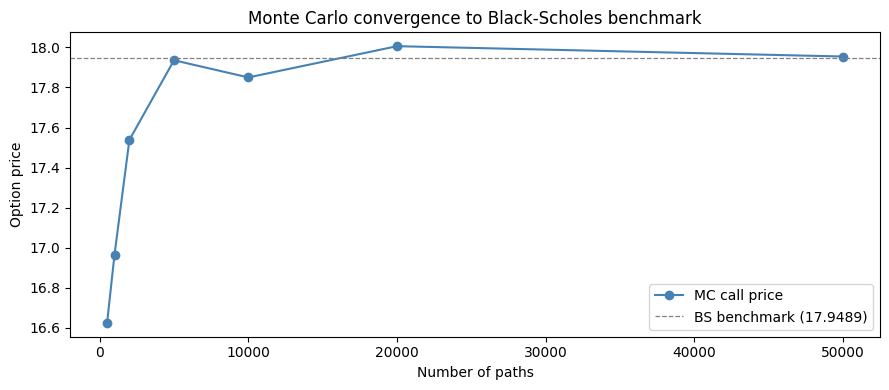

In [8]:
path_counts = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]
mc_conv = [MonteCarlo(n_paths=n).price(call_params).price for n in path_counts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(path_counts, mc_conv, marker="o", color="steelblue", label="MC call price")
ax.axhline(bs_call.price, linestyle="--", color="gray", linewidth=0.9, label=f"BS benchmark ({bs_call.price:.4f})")
ax.set_xlabel("Number of paths")
ax.set_ylabel("Option price")
ax.set_title("Monte Carlo convergence to Black-Scholes benchmark")
ax.legend()
plt.tight_layout()
plt.show()

## Binomial Tree — CRR Lattice

Builds a discrete recombining tree of possible stock prices (Cox-Ross-Rubinstein parameterisation) and solves for the option value by backward induction. Prices both European options (no early exercise) and American options (early exercise allowed at every node — relevant for puts).

In [9]:
bt_call_eur = BinomialTree(steps=500).price(call_params)
bt_put_eur  = BinomialTree(steps=500).price(put_params)
bt_put_amer = BinomialTree(steps=500, american=True).price(put_params)

print(f"Binomial Tree Call — European (500 steps): {bt_call_eur.price:.4f}  |  vs BS: {bt_call_eur.price - bs_call.price:+.4f}")
print(f"Binomial Tree Put  — European (500 steps): {bt_put_eur.price:.4f}  |  vs BS: {bt_put_eur.price - bs_put.price:+.4f}")
print(f"Binomial Tree Put  — American (500 steps): {bt_put_amer.price:.4f}  |  early exercise premium: {bt_put_amer.price - bt_put_eur.price:+.4f}")

Binomial Tree Call — European (500 steps): 17.9570  |  vs BS: +0.0081
Binomial Tree Put  — European (500 steps): 19.0086  |  vs BS: +0.0081
Binomial Tree Put  — American (500 steps): 19.5296  |  early exercise premium: +0.5210


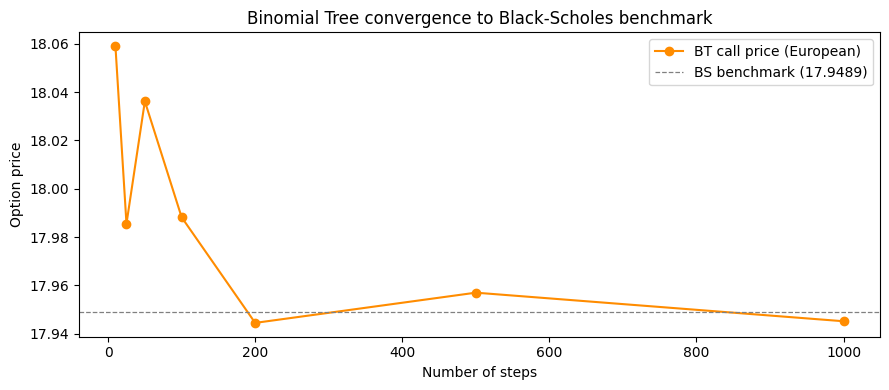

In [10]:
step_counts = [10, 25, 50, 100, 200, 500, 1000]
bt_conv = [BinomialTree(steps=n).price(call_params).price for n in step_counts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(step_counts, bt_conv, marker="o", color="darkorange", label="BT call price (European)")
ax.axhline(bs_call.price, linestyle="--", color="gray", linewidth=0.9, label=f"BS benchmark ({bs_call.price:.4f})")
ax.set_xlabel("Number of steps")
ax.set_ylabel("Option price")
ax.set_title("Binomial Tree convergence to Black-Scholes benchmark")
ax.legend()
plt.tight_layout()
plt.show()

## Method Comparison

In [11]:
labels      = ["Black-Scholes", "Monte Carlo\n(50k paths)", "Binomial Tree\n(500 steps)"]
call_prices = [bs_call.price, mc_call.price, bt_call_eur.price]
put_prices  = [bs_put.price,  mc_put.price,  bt_put_eur.price]

print(f"{'Method':<25} {'Call':>10} {'Put':>10} {'Call vs BS':>12} {'Put vs BS':>12}")
print("-" * 70)
for label, c, p in zip(["Black-Scholes", "Monte Carlo (50k)", "Binomial Tree (500)"], call_prices, put_prices):
    call_diff = f"{c - bs_call.price:+.4f}" if label != "Black-Scholes" else "—"
    put_diff  = f"{p - bs_put.price:+.4f}"  if label != "Black-Scholes" else "—"
    print(f"{label:<25} {c:>10.4f} {p:>10.4f} {call_diff:>12} {put_diff:>12}")

Method                          Call        Put   Call vs BS    Put vs BS
----------------------------------------------------------------------
Black-Scholes                17.9489    19.0005            —            —
Monte Carlo (50k)            17.9544    18.9908      +0.0055      -0.0097
Binomial Tree (500)          17.9570    19.0086      +0.0081      +0.0081


## Greeks

Sensitivities of the option price to each model input. Analytical Greeks use the closed-form Merton formulas. Numerical Greeks use central finite differences applied to the Binomial Tree pricer — useful for models without closed-form solutions.

In [12]:
from src.pricing import AnalyticalGreeks, NumericalGreeks

ag = AnalyticalGreeks()
ng = NumericalGreeks(BinomialTree(steps=300))

g_call_a = ag.compute(call_params)
g_put_a  = ag.compute(put_params)
g_call_n = ng.compute(call_params)
g_put_n  = ng.compute(put_params)

print(f"{'Greek':<8} {'BS-Analyt Call':>16} {'BS-Analyt Put':>16} {'BT-Numer Call':>16} {'BT-Numer Put':>16}")
print("-" * 74)
for greek in ["delta", "gamma", "vega", "theta", "rho"]:
    ca = getattr(g_call_a, greek)
    pa = getattr(g_put_a,  greek)
    cn = getattr(g_call_n, greek)
    pn = getattr(g_put_n,  greek)
    print(f"{greek:<8} {ca:>16.6f} {pa:>16.6f} {cn:>16.6f} {pn:>16.6f}")

Greek      BS-Analyt Call    BS-Analyt Put    BT-Numer Call     BT-Numer Put
--------------------------------------------------------------------------
delta            0.521662        -0.476490         0.527592        -0.472408
gamma            0.008578         0.008578         0.079942        -0.046777
vega             0.820070         0.820070         0.815758         0.815758
theta           -0.062216        -0.036265        -0.063624        -0.034722
rho              0.671139        -0.789998         0.677768        -0.783369


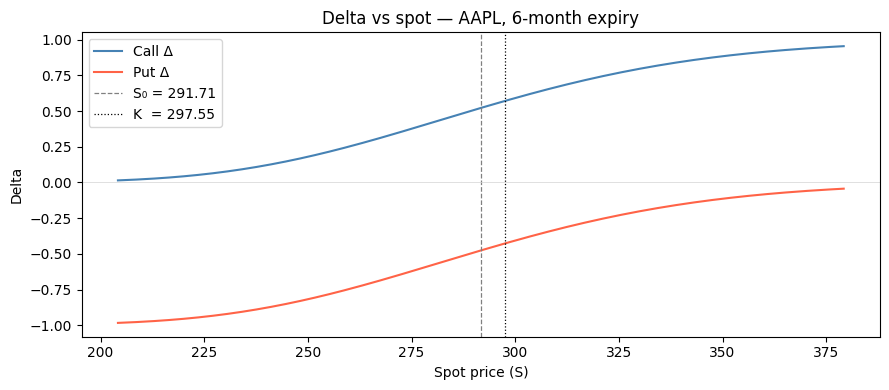

In [13]:
spot_range = np.linspace(S0 * 0.7, S0 * 1.3, 200)
deltas_call = [ag.compute(OptionParams(S=s, K=K, T=T, r=rf, sigma=sigma, option_type="call", q=q)).delta for s in spot_range]
deltas_put  = [ag.compute(OptionParams(S=s, K=K, T=T, r=rf, sigma=sigma, option_type="put",  q=q)).delta for s in spot_range]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(spot_range, deltas_call, label="Call Δ", color="steelblue")
ax.plot(spot_range, deltas_put,  label="Put Δ",  color="tomato")
ax.axvline(S0, linestyle="--", color="gray",  linewidth=0.9, label=f"S₀ = {S0:.2f}")
ax.axvline(K,  linestyle=":",  color="black", linewidth=0.9, label=f"K  = {K:.2f}")
ax.axhline(0,  color="lightgray", linewidth=0.5)
ax.set_xlabel("Spot price (S)")
ax.set_ylabel("Delta")
ax.set_title("Delta vs spot — AAPL, 6-month expiry")
ax.legend()
plt.tight_layout()
plt.show()

## Implied Volatility Surface

### Volatility surface with Brent's root-finding

Extracts the market-implied volatility from each live AAPL option price by inverting the Black-Scholes formula (Brent's root-finding). Iterating across all expiries and strikes produces the full vol surface — the market's forward-looking view of uncertainty at each tenor and moneyness.

In [14]:
import pandas as pd
from scipy.interpolate import griddata
from src.pricing import build_vol_surface

# Build chain DataFrame from fetched option_chain dict
today = pd.Timestamp.now().normalize()
rows = []
for exp, chains in option_chain.items():
    T_exp = (pd.Timestamp(exp) - today).days / 365.0
    if T_exp < 30 / 365:  # drop near-expiry options — inherently unstable IV
        continue
    df = chains["calls"].copy()
    df = df[
        (df["volume"] > 0) &
        (df["openInterest"] > 0) &
        (df["bid"].notna()) & (df["bid"] > 0) &   # bid == 0 → illiquid, solver returns garbage
        (df["ask"] > 0)
    ]
    df["mid_price"] = (df["bid"] + df["ask"]) / 2
    df["expiry"] = exp
    df["T"] = T_exp
    rows.append(df[["expiry", "strike", "mid_price", "T"]])

chain_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["expiry", "strike", "mid_price", "T"])
chain_df = chain_df[(chain_df["strike"] >= S0 * 0.7) & (chain_df["strike"] <= S0 * 1.3)]

# Build surface, drop NaN, then filter outlier IVs
surface = build_vol_surface(chain_df, S=S0, r=rf, option_type="call", q=q)
surface_clean = surface.dropna().reset_index()
T_map = chain_df.groupby("expiry")["T"].first()
surface_clean["T"] = surface_clean["expiry"].map(T_map)
surface_clean = surface_clean[
    (surface_clean["implied_vol"] >= 0.01) &
    (surface_clean["implied_vol"] <= 2.0)
]

# Interpolate scattered (T, strike) points onto a regular grid
T_grid = np.linspace(surface_clean["T"].min(), surface_clean["T"].max(), 60)
K_grid = np.linspace(surface_clean["strike"].min(), surface_clean["strike"].max(), 60)
TT, KK = np.meshgrid(T_grid, K_grid)
IV_grid = griddata(
    points=surface_clean[["T", "strike"]].values,
    values=surface_clean["implied_vol"].values,
    xi=(TT, KK),
    method="cubic",
)
IV_grid = np.clip(IV_grid, 0.05, 0.80)

print(f"Surface points after filtering: {len(surface_clean)}")
print(f"Implied vol range: {surface_clean['implied_vol'].min():.1%} – {surface_clean['implied_vol'].max():.1%}")
surface_clean.head(8)

Surface points after filtering: 317
Implied vol range: 21.3% – 60.9%


,expiry,strike,implied_vol,T
0,2026-06-12,230.0,0.527561,0.087671
1,2026-06-12,235.0,0.487657,0.087671
2,2026-06-12,240.0,0.471443,0.087671
3,2026-06-12,245.0,0.416327,0.087671
4,2026-06-12,250.0,0.397629,0.087671
5,2026-06-12,255.0,0.371923,0.087671
6,2026-06-12,260.0,0.357105,0.087671
7,2026-06-12,265.0,0.314897,0.087671


In [15]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(
    x=TT,
    y=KK,
    z=IV_grid * 100,
    colorscale="RdYlGn_r",
    colorbar=dict(title="Implied vol (%)"),
)])
fig.update_layout(
    title="AAPL Implied Volatility Surface — calls",
    scene=dict(
        xaxis_title="T (years)",
        yaxis_title="Strike",
        zaxis_title="Implied vol (%)",
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

### Volatility surface with yfinance data

In [16]:
import yfinance as yf

aapl = yf.Ticker("AAPL")

option_chain = {}
for exp in aapl.options:
    chain = aapl.option_chain(exp)
    option_chain[exp] = {
        "calls": chain.calls.copy(),
        "puts": chain.puts.copy()
    }

S0 = float(aapl.fast_info["last_price"])

print(f"S0: {S0:.2f}")
print(f"Expiries: {len(option_chain)}")
print(f"Sample columns: {list(option_chain[aapl.options[0]]['calls'].columns)}")
print(option_chain[aapl.options[0]]["calls"][["strike", "impliedVolatility", "bid", "ask", "volume"]].head(5))

S0: 292.24
Expiries: 25
Sample columns: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']
   strike  impliedVolatility    bid    ask  volume
0   230.0           2.347660  59.15  62.55     2.0
1   242.5           2.078130  46.90  50.25     NaN
2   245.0           1.810548  44.80  47.55    30.0
3   250.0           1.634767  38.95  42.55   444.0
4   252.5           1.546877  36.40  40.05     1.0


In [17]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import griddata

today = pd.Timestamp.now().normalize()
rows = []

for exp, chains in option_chain.items():
    T_exp = (pd.Timestamp(exp) - today).days / 365.0
    if T_exp < 30 / 365:
        continue

    df = chains["calls"].copy()
    df = df[
        (df["impliedVolatility"] > 0.01) &
        (df["impliedVolatility"] < 2.0) &
        (df["impliedVolatility"].notna()) &
        (df["bid"] > 0) &
        (df["ask"] > 0)
    ]
    df["expiry"] = exp
    df["T"] = T_exp
    rows.append(df[["expiry", "strike", "impliedVolatility", "T"]])

chain_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

chain_df = chain_df[
    (chain_df["strike"] >= S0 * 0.7) &
    (chain_df["strike"] <= S0 * 1.3)
]

print(f"Surface points: {len(chain_df)}")
print(f"Expiries: {chain_df['expiry'].nunique()}")
print(f"IV range: {chain_df['impliedVolatility'].min():.1%} – {chain_df['impliedVolatility'].max():.1%}")

T_grid = np.linspace(chain_df["T"].min(), chain_df["T"].max(), 60)
K_grid = np.linspace(chain_df["strike"].min(), chain_df["strike"].max(), 60)
TT, KK = np.meshgrid(T_grid, K_grid)
IV_grid = griddata(
    points=chain_df[["T", "strike"]].values,
    values=chain_df["impliedVolatility"].values,
    xi=(TT, KK),
    method="cubic",
)
IV_grid = np.clip(IV_grid, 0.05, 0.80)

fig = go.Figure(data=[go.Surface(
    x=TT,
    y=KK,
    z=IV_grid * 100,
    colorscale="RdYlGn_r",
    colorbar=dict(title="Implied vol (%)"),
)])
fig.update_layout(
    title="AAPL Implied Volatility Surface — yfinance IV (calls)",
    scene=dict(
        xaxis_title="T (years)",
        yaxis_title="Strike",
        zaxis_title="Implied vol (%)",
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()


Surface points: 440
Expiries: 17
IV range: 23.5% – 72.0%
